In [9]:
import os
from glob import glob
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Label map: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}


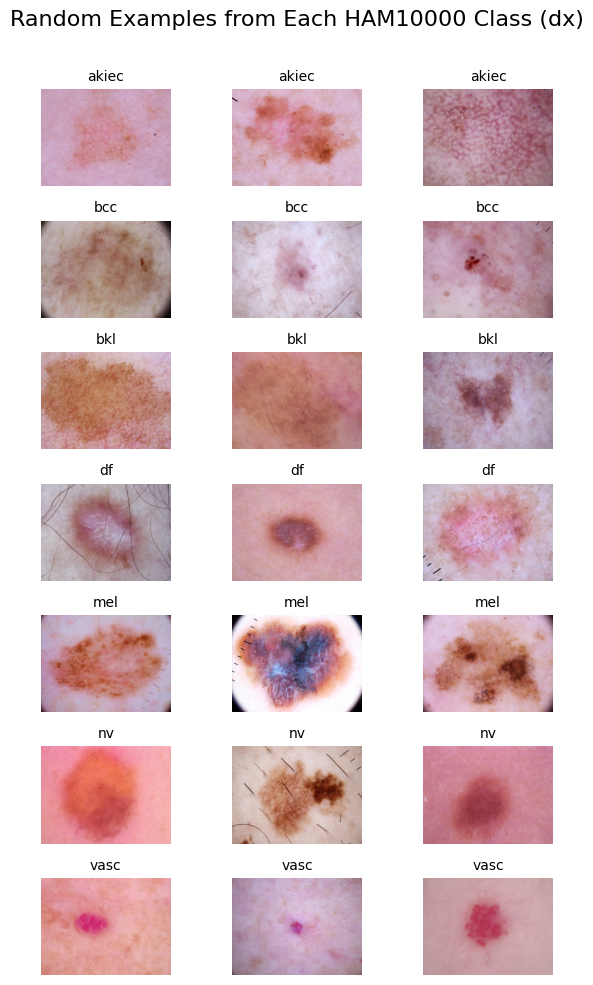

In [10]:
# 3 random images from each class

import matplotlib.pyplot as plt
import random

random.seed(42)
metadata = pd.read_csv("/content/drive/MyDrive/HAM10000/HAM10000_metadata")
class_names = sorted(metadata["dx"].unique())
labels = metadata["dx"].unique()
label_map = {name: i for i, name in enumerate(labels)}
metadata["label"] = metadata["dx"].map(label_map)
print("Label map:", label_map)

paths_part1 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part1/*.jpg")
paths_part2 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part2/*.jpg")
all_paths = paths_part1 + paths_part2

id_to_path = {os.path.basename(p)[:-4]: p for p in all_paths}

n_classes = len(class_names)
n_per_class = 3

fig, axes = plt.subplots(n_classes, n_per_class, figsize=(6,10))

if n_classes == 1:
    axes = np.expand_dims(axes, axis=0)
if n_per_class == 1:
    axes = np.expand_dims(axes, axis=1)

for row_idx, cls in enumerate(class_names):
    rows_cls = metadata[metadata["dx"] == cls]
    sampled = rows_cls.sample(n=n_per_class, random_state=42)
    for col_idx, (_, row) in enumerate(sampled.iterrows()):
        img_id = row["image_id"]
        img_path = id_to_path[img_id]
        img = Image.open(img_path).convert("RGB")
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=12, rotation=0, labelpad=35, va="center")
        ax.set_title(cls, fontsize=10)

plt.suptitle("Random Examples from Each HAM10000 Class (dx)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


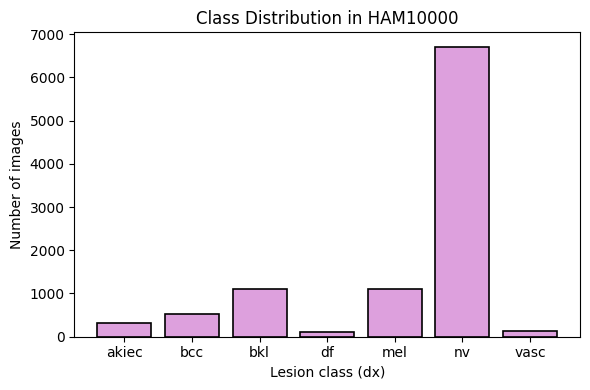

In [11]:
class_counts = metadata["dx"].value_counts().sort_index()
class_names = class_counts.index.tolist()
counts = class_counts.values

plt.figure(figsize=(6, 4))
bars = plt.bar(
    class_names,
    counts,
    color="plum",
    edgecolor="black",
    linewidth=1.2
)

plt.xlabel("Lesion class (dx)")
plt.ylabel("Number of images")
plt.title("Class Distribution in HAM10000")
plt.xticks()
plt.tight_layout()
plt.show()


In [13]:
import os
from glob import glob
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# selects training device
# if a GPU is not available, run on the CPU (but GPU is much faster for CNNs)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load metadata
metadata = pd.read_csv("/content/drive/MyDrive/HAM10000/HAM10000_metadata")

# converts the label, the diagnosis (dx), into numeric labels (0–6)
labels = metadata["dx"].unique()
label_map = {name: i for i, name in enumerate(labels)}
metadata["label"] = metadata["dx"].map(label_map)
print("Label map:", label_map)

# map image ids to image files
paths_part1 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part1/*.jpg")
paths_part2 = glob("/content/drive/MyDrive/HAM10000/HAM10000_part2/*.jpg")
all_paths = paths_part1 + paths_part2

id_to_path = {os.path.basename(p)[:-4]: p for p in all_paths}
print("Total images found:", len(id_to_path))

# initialize lists to store image paths and their labels
image_paths = []
image_labels = []

for _, row in metadata.iterrows():
    img_id = row["image_id"]
    if img_id in id_to_path:
        image_paths.append(id_to_path[img_id])
        image_labels.append(row["label"])

print("Total usable images:", len(image_paths))

# train/validation split
# once we tune hyperparameters we can include a test set
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.2,
    stratify=image_labels, # makes class proportions consistent for training and validation
    random_state=42
)

print("Train size:", len(train_paths), "Val size:", len(val_paths))

baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

flip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

rotation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

jitter_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

grayscale_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

heavy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

moderate_transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.RandomRotation(20),
transforms.ColorJitter(brightness=0.1, contrast=0.1),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406],
                     [0.229, 0.224, 0.225])
])


### IF ADDING TRANSFORMS, ADD THEM HERE ###

# define image transforms for training images
val_transform = transforms.Compose([
    # make every image the same size
    transforms.Resize((224, 224)),
    # convert PIL image into PyTorch tensor and scale pixel values from 0-255 to 0-1
    transforms.ToTensor(),
    # standardize each channel (match what EfficientNet was trained on)
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_grayscale_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# helper function that loads one image at a time and applies transformation
def load_image_tensor(path, transform):
    img = Image.open(path).convert("RGB")
    img = transform(img)
    return img

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Label map: {'bkl': 0, 'nv': 1, 'df': 2, 'mel': 3, 'vasc': 4, 'bcc': 5, 'akiec': 6}
Total images found: 10015
Total usable images: 10015
Train size: 8012 Val size: 2003


In [20]:
def run_experiment(experiment_name, train_transform, val_transform,
                   epochs, batch_size=64):

    print("\n==========================")
    print("Running experiment: %s" % experiment_name)
    print("==========================\n")

    scaler = torch.cuda.amp.GradScaler()

    weights = EfficientNet_B5_Weights.DEFAULT
    model = efficientnet_b5(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(label_map))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_val_acc = 0.0

    counter = 3
    no_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        indices = np.random.permutation(len(train_paths))

        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start:start + batch_size]
            batch_imgs = []
            batch_labs = []

            for idx in batch_idx:
                img_tensor = load_image_tensor(train_paths[idx], train_transform)
                batch_imgs.append(img_tensor)
                batch_labs.append(train_labels[idx])

            images = torch.stack(batch_imgs).to(device)
            labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()


            running_loss += loss.item()

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for start in range(0, len(val_paths), batch_size):
                batch_paths = val_paths[start:start + batch_size]
                batch_labs = val_labels[start:start + batch_size]

                batch_imgs = [load_image_tensor(p, val_transform) for p in batch_paths]
                images = torch.stack(batch_imgs).to(device)
                labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

                outputs = model(images)
                outputs = outputs.detach().cpu()
                _, preds = torch.max(outputs, 1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = float(correct) / float(total)

        print("Epoch %d/%d - loss=%.3f, val_acc=%.2f%%" %
              (epoch + 1, epochs, running_loss, val_acc * 100.0))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model_%s.pth" % experiment_name)
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= counter:
            print("Stopping early due to no more improvement in 3 consecutive epochs.")
            break

    print("\nBest validation accuracy for %s: %.2f%%" %
          (experiment_name, best_val_acc * 100.0))
    return best_val_acc


In [ ]:
acc_baseline = run_experiment(
    experiment_name="baseline",
    train_transform=baseline_transform,
    val_transform=val_transform,
    epochs=20
)


Running experiment: baseline



/tmp/ipython-input-3801972130.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3801972130.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - loss=127.669, val_acc=70.00%
Epoch 2/20 - loss=60.070, val_acc=82.28%
Epoch 3/20 - loss=29.764, val_acc=84.67%
Epoch 4/20 - loss=15.178, val_acc=83.42%
Epoch 5/20 - loss=8.494, val_acc=84.82%
Epoch 6/20 - loss=8.076, val_acc=84.62%
Epoch 7/20 - loss=4.974, val_acc=85.57%
Epoch 8/20 - loss=4.372, val_acc=85.77%
Epoch 9/20 - loss=4.777, val_acc=85.52%
Epoch 10/20 - loss=3.261, val_acc=86.02%
Epoch 11/20 - loss=2.362, val_acc=85.77%
Epoch 12/20 - loss=2.421, val_acc=85.42%
Epoch 13/20 - loss=2.185, val_acc=85.62%
Stopping early due to no more improvement in 3 consecutive epochs.

Best validation accuracy for baseline: 86.02%


In [ ]:

acc_flip = run_experiment(
    experiment_name="flip",
    train_transform=flip_transform,
    val_transform=val_transform,
    epochs=20
)


Running experiment: flip



/tmp/ipython-input-3801972130.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3801972130.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - loss=126.614, val_acc=69.35%
Epoch 2/20 - loss=68.567, val_acc=81.33%
Epoch 3/20 - loss=49.659, val_acc=84.12%
Epoch 4/20 - loss=35.662, val_acc=85.27%
Epoch 5/20 - loss=26.313, val_acc=85.02%
Epoch 6/20 - loss=20.510, val_acc=86.32%
Epoch 7/20 - loss=15.269, val_acc=86.92%
Epoch 8/20 - loss=12.266, val_acc=87.52%
Epoch 9/20 - loss=9.049, val_acc=87.87%
Epoch 10/20 - loss=8.842, val_acc=88.42%
Epoch 11/20 - loss=7.113, val_acc=87.87%
Epoch 12/20 - loss=6.987, val_acc=87.87%
Epoch 13/20 - loss=6.456, val_acc=88.12%
Stopping early due to no more improvement in 3 consecutive epochs.

Best validation accuracy for flip: 88.42%


In [ ]:

acc_rotation = run_experiment(
    experiment_name="rotation",
    train_transform=rotation_transform,
    val_transform=val_transform,
    epochs=20
)


Running experiment: rotation



/tmp/ipython-input-3801972130.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3801972130.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - loss=129.525, val_acc=73.69%
Epoch 2/20 - loss=70.167, val_acc=81.83%
Epoch 3/20 - loss=51.520, val_acc=85.62%
Epoch 4/20 - loss=38.338, val_acc=85.67%
Epoch 5/20 - loss=30.466, val_acc=83.67%
Epoch 6/20 - loss=23.259, val_acc=86.67%
Epoch 7/20 - loss=17.243, val_acc=89.02%
Epoch 8/20 - loss=14.838, val_acc=86.87%
Epoch 9/20 - loss=12.352, val_acc=88.42%
Epoch 10/20 - loss=8.350, val_acc=88.32%
Stopping early due to no more improvement in 3 consecutive epochs.

Best validation accuracy for rotation: 89.02%


In [ ]:

acc_jitter = run_experiment(
    experiment_name="jitter",
    train_transform=jitter_transform,
    val_transform=val_transform,
    epochs=20
)


Running experiment: jitter



/tmp/ipython-input-3801972130.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3801972130.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - loss=129.571, val_acc=71.04%
Epoch 2/20 - loss=64.642, val_acc=82.28%
Epoch 3/20 - loss=37.511, val_acc=84.42%
Epoch 4/20 - loss=21.047, val_acc=85.62%
Epoch 5/20 - loss=12.415, val_acc=85.67%
Epoch 6/20 - loss=9.474, val_acc=85.92%
Epoch 7/20 - loss=7.044, val_acc=86.42%
Epoch 8/20 - loss=5.188, val_acc=87.07%
Epoch 9/20 - loss=3.969, val_acc=85.52%
Epoch 10/20 - loss=5.391, val_acc=86.27%
Epoch 11/20 - loss=3.286, val_acc=85.87%
Stopping early due to no more improvement in 3 consecutive epochs.

Best validation accuracy for jitter: 87.07%


In [ ]:

acc_grayscale = run_experiment(
    experiment_name="grayscale",
    train_transform=grayscale_transform,
    val_transform=val_grayscale_transform,
    epochs=20
)


Running experiment: grayscale



/tmp/ipython-input-3801972130.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3801972130.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - loss=132.507, val_acc=69.35%
Epoch 2/20 - loss=70.834, val_acc=76.68%
Epoch 3/20 - loss=41.686, val_acc=78.03%
Epoch 4/20 - loss=21.562, val_acc=75.64%
Epoch 5/20 - loss=13.491, val_acc=78.28%
Epoch 6/20 - loss=8.021, val_acc=81.63%
Epoch 7/20 - loss=4.208, val_acc=81.68%
Epoch 8/20 - loss=6.092, val_acc=79.88%
Epoch 9/20 - loss=6.400, val_acc=81.48%
Epoch 10/20 - loss=5.140, val_acc=81.83%
Epoch 11/20 - loss=4.109, val_acc=82.83%
Epoch 12/20 - loss=4.078, val_acc=80.43%
Epoch 13/20 - loss=4.150, val_acc=80.98%
Epoch 14/20 - loss=2.476, val_acc=81.13%
Stopping early due to no more improvement in 3 consecutive epochs.

Best validation accuracy for grayscale: 82.83%


In [ ]:

acc_heavy_aug = run_experiment(
    experiment_name="heavy",
    train_transform=heavy_transform,
    val_transform=val_transform,
    epochs=20
)

## ADD MORE TRANSFORMS BELOW THIS CELL ##


Running experiment: heavy



/tmp/ipython-input-3801972130.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3801972130.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 - loss=130.362, val_acc=71.89%
Epoch 2/20 - loss=72.579, val_acc=81.93%
Epoch 3/20 - loss=55.328, val_acc=85.27%
Epoch 4/20 - loss=44.234, val_acc=86.57%
Epoch 5/20 - loss=36.297, val_acc=86.02%
Epoch 6/20 - loss=27.448, val_acc=86.47%
Epoch 7/20 - loss=23.447, val_acc=87.32%
Epoch 8/20 - loss=19.730, val_acc=87.07%
Epoch 9/20 - loss=17.522, val_acc=87.67%
Epoch 10/20 - loss=13.772, val_acc=87.27%
Epoch 11/20 - loss=11.759, val_acc=87.97%
Epoch 12/20 - loss=10.655, val_acc=87.77%
Epoch 13/20 - loss=10.560, val_acc=87.32%
Epoch 14/20 - loss=7.669, val_acc=89.27%
Epoch 15/20 - loss=7.683, val_acc=88.62%
Epoch 16/20 - loss=6.831, val_acc=87.97%
Epoch 17/20 - loss=5.119, val_acc=88.52%
Stopping early due to no more improvement in 3 consecutive epochs.

Best validation accuracy for heavy: 89.27%


In [21]:

acc_moderate = run_experiment(
    experiment_name="moderate",
    train_transform=moderate_transform,
    val_transform=val_transform,
    epochs=20
)


Running experiment: moderate



/tmp/ipython-input-3964511506.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3964511506.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


KeyboardInterrupt: 

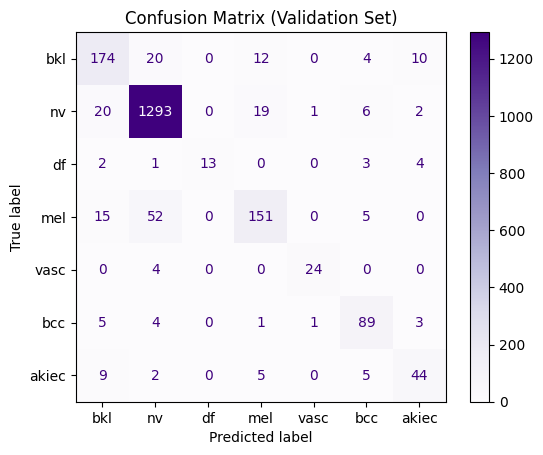

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# rebuild model but with no weights
model_cm = efficientnet_b5(weights=None)
num_classes = len(label_map)
model_cm.classifier[1] = nn.Linear(model_cm.classifier[1].in_features, num_classes)
model_cm = model_cm.to(device)

# load best saved weights
state_dict = torch.load("best_model_heavy.pth", map_location=device)
model_cm.load_state_dict(state_dict)
model_cm.eval()

# collect predictions from validation set
all_true = []
all_preds = []
batch_size = 32
with torch.no_grad():
    for start in range(0, len(val_paths), batch_size):
        batch_paths = val_paths[start:start + batch_size]
        batch_labs = val_labels[start:start + batch_size]

        batch_imgs = []
        for path in batch_paths:
            img_tensor = load_image_tensor(path, val_transform)
            batch_imgs.append(img_tensor)

        images = torch.stack(batch_imgs).to(device)
        labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

        outputs = model_cm(images)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# make confusion matrix
cm = confusion_matrix(all_true, all_preds)
class_names = list(label_map.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix (Validation Set)")
plt.show()




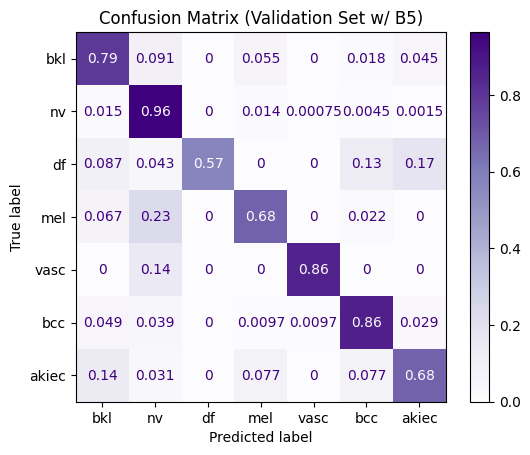

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# rebuild model but with no weights
model_cm = efficientnet_b5(weights=None)
num_classes = len(label_map)
model_cm.classifier[1] = nn.Linear(model_cm.classifier[1].in_features, num_classes)
model_cm = model_cm.to(device)

# load best saved weights
state_dict = torch.load("best_model_heavy.pth", map_location=device)
model_cm.load_state_dict(state_dict)
model_cm.eval()

# collect predictions from validation set
all_true = []
all_preds = []

with torch.no_grad():
    for start in range(0, len(val_paths), batch_size):
        batch_paths = val_paths[start:start + batch_size]
        batch_labs = val_labels[start:start + batch_size]

        batch_imgs = []
        for path in batch_paths:
            img_tensor = load_image_tensor(path, val_transform)
            batch_imgs.append(img_tensor)

        images = torch.stack(batch_imgs).to(device)
        labels = torch.tensor(batch_labs, dtype=torch.long).to(device)

        outputs = model_cm(images)
        _, preds = torch.max(outputs, 1)

        all_true.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# make confusion matrix
cm = confusion_matrix(all_true, all_preds, normalize='true')
class_names = list(label_map.keys())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix (Validation Set w/ B5)")
plt.show()

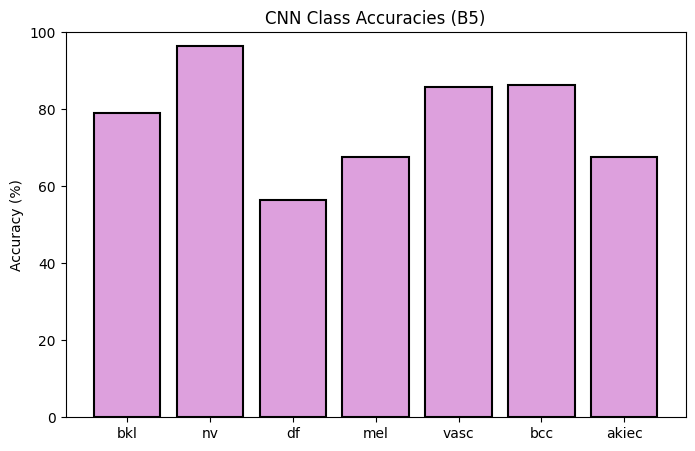

In [ ]:
counts = cm.sum(axis=1)
tp = np.diag(cm)
class_accuracies = np.divide(tp, counts)*100

plt.figure(figsize=(8,5))

bars = plt.bar(class_names, class_accuracies,
               color="plum",
               edgecolor='black',
               linewidth=1.5)

plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.title("CNN Class Accuracies (B5)")

plt.show()
